# 方差过滤

In [1]:
#1.导入所需要的库
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
# 2.导入数据集，探索数据
data = pd.read_csv(r"E:\高密度脑电前额项目\code\EEG\feature_analysis\HD\jiao\trial1\clean\jiao.csv")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Columns: 385 entries, mean_0 to Label
dtypes: float64(385)
memory usage: 1.5 MB


In [3]:
data.shape

(504, 385)

In [4]:
data.head()

,mean_0,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,...,DE_39,DE_40,DE_41,DE_42,DE_43,DE_44,DE_45,DE_46,DE_47,Label
0,0.107,0.0751,0.2710,-0.0472,0.1380,0.21300,-0.0289,0.0498,-0.0271,0.0742,...,2.23,2.13,2.16,2.23,2.16,1.84,2.59,2.07,2.25,2.0
1,0.684,0.2260,-0.7100,1.0500,0.0512,-0.63000,1.1000,0.0439,-0.0301,0.9160,...,2.68,3.13,3.78,2.73,2.26,3.35,2.98,2.36,2.88,1.0
2,0.446,0.1290,-0.1970,0.6590,0.0389,-0.40400,0.6690,-0.0141,-0.0264,0.6740,...,2.43,2.74,3.28,2.66,2.17,2.92,2.83,2.30,2.49,0.0
3,-0.303,-0.2420,-0.0656,-0.6590,-0.0337,0.05050,-0.6440,-0.0460,-0.0130,-0.2650,...,2.54,2.30,2.23,2.37,2.05,2.23,2.80,2.17,2.22,2.0
4,0.272,-0.0915,-0.1410,0.6300,0.3740,-0.00429,0.6780,0.2210,0.2010,1.1100,...,3.03,3.42,4.17,3.04,2.75,3.71,3.16,2.32,3.43,0.0


In [5]:
data.describe()

,mean_0,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,...,DE_39,DE_40,DE_41,DE_42,DE_43,DE_44,DE_45,DE_46,DE_47,Label
count,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.00000,504.000000,504.000000,...,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000
mean,-0.003847,-0.000573,0.001426,-0.009158,-0.002362,0.002239,-0.009101,-0.00024,-0.000045,-0.006087,...,2.583790,2.549544,2.957560,2.592540,2.321369,2.695337,3.033988,2.297560,2.581429,1.000000
std,0.524199,0.264173,0.512859,0.937042,0.310443,0.467054,0.947978,0.34708,0.352380,1.070074,...,0.343885,0.491191,0.762013,0.356215,0.343238,0.658408,0.387684,0.235636,0.517268,0.817308
min,-2.800000,-0.848000,-1.800000,-6.150000,-1.520000,-1.720000,-6.160000,-1.87000,-1.860000,-6.000000,...,2.040000,1.750000,1.950000,2.000000,1.740000,1.710000,2.080000,1.810000,1.640000,0.000000
25%,-0.247250,-0.165250,-0.282250,-0.311250,-0.163250,-0.248500,-0.315750,-0.14625,-0.155000,-0.367250,...,2.340000,2.180000,2.317500,2.330000,2.080000,2.150000,2.747500,2.130000,2.157500,0.000000
50%,0.018450,0.000639,0.006140,0.013500,-0.003715,-0.001277,0.024150,0.00381,-0.001729,0.024300,...,2.475000,2.365000,2.620000,2.480000,2.230000,2.420000,3.040000,2.260000,2.410000,1.000000
75%,0.246000,0.151750,0.267250,0.342250,0.156750,0.253000,0.316750,0.16475,0.162750,0.349250,...,2.782500,2.865000,3.680000,2.870000,2.490000,3.262500,3.330000,2.430000,2.967500,2.000000
max,2.000000,0.971000,3.510000,3.530000,1.120000,3.310000,3.530000,3.01000,3.090000,4.890000,...,3.900000,4.050000,4.800000,3.630000,4.160000,4.450000,4.360000,3.320000,4.030000,2.000000


In [6]:
from sklearn.preprocessing import LabelEncoder
y = data.iloc[:,-1]#要输入的是标签，不是特征矩阵，所以允许一维

In [7]:
le = LabelEncoder()  # 实例化
le = le.fit(y) # 导入数据
label = le.transform(y) # transform接口调取数据
le.classes_  #属性.classes_查看标签中究竟有多少类别
label

array([2, 1, 0, 2, 0, 2, 2, 2, 2, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 2, 1, 0,
       0, 2, 2, 0, 1, 0, 1, 2, 0, 0, 2, 1, 2, 0, 2, 1, 1, 2, 1, 2, 1, 1,
       2, 1, 1, 1, 2, 0, 0, 0, 2, 2, 1, 0, 2, 0, 1, 2, 0, 2, 2, 0, 1, 2,
       2, 0, 1, 2, 0, 1, 0, 0, 2, 1, 0, 1, 1, 1, 0, 1, 1, 1, 2, 2, 0, 0,
       2, 1, 0, 2, 0, 2, 2, 2, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2,
       0, 2, 0, 1, 1, 2, 2, 2, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       2, 0, 2, 1, 1, 1, 2, 1, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2,
       0, 2, 2, 1, 2, 0, 2, 2, 0, 2, 0, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1, 1,
       1, 2, 2, 2, 1, 0, 2, 1, 2, 1, 0, 0, 2, 2, 1, 1, 0, 1, 1, 2, 1, 0,
       2, 0, 2, 1, 2, 1, 2, 1, 0, 2, 2, 0, 2, 2, 1, 2, 2, 0, 2, 2, 1, 0,
       0, 1, 2, 1, 2, 0, 1, 1, 2, 2, 2, 2, 0, 2, 2, 0, 0, 1, 1, 0, 2, 1,
       2, 1, 0, 0, 0, 2, 1, 2, 2, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 2, 1, 0,
       1, 1, 2, 1, 2, 2, 1, 0, 1, 2, 1, 0, 0, 1, 1, 0, 1, 0, 2, 2, 2, 0,
       0, 0, 1, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 1, 2,

In [8]:
le.fit_transform(y)  #也可以直接fit_transform一步到位

array([2, 1, 0, 2, 0, 2, 2, 2, 2, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 2, 1, 0,
       0, 2, 2, 0, 1, 0, 1, 2, 0, 0, 2, 1, 2, 0, 2, 1, 1, 2, 1, 2, 1, 1,
       2, 1, 1, 1, 2, 0, 0, 0, 2, 2, 1, 0, 2, 0, 1, 2, 0, 2, 2, 0, 1, 2,
       2, 0, 1, 2, 0, 1, 0, 0, 2, 1, 0, 1, 1, 1, 0, 1, 1, 1, 2, 2, 0, 0,
       2, 1, 0, 2, 0, 2, 2, 2, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2,
       0, 2, 0, 1, 1, 2, 2, 2, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       2, 0, 2, 1, 1, 1, 2, 1, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2,
       0, 2, 2, 1, 2, 0, 2, 2, 0, 2, 0, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1, 1,
       1, 2, 2, 2, 1, 0, 2, 1, 2, 1, 0, 0, 2, 2, 1, 1, 0, 1, 1, 2, 1, 0,
       2, 0, 2, 1, 2, 1, 2, 1, 0, 2, 2, 0, 2, 2, 1, 2, 2, 0, 2, 2, 1, 0,
       0, 1, 2, 1, 2, 0, 1, 1, 2, 2, 2, 2, 0, 2, 2, 0, 0, 1, 1, 0, 2, 1,
       2, 1, 0, 0, 0, 2, 1, 2, 2, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 2, 1, 0,
       1, 1, 2, 1, 2, 2, 1, 0, 1, 2, 1, 0, 0, 1, 1, 0, 1, 0, 2, 2, 2, 0,
       0, 0, 1, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 1, 2,

In [9]:
le.inverse_transform(label)  #使用inverse_transform可以逆转

array([2., 1., 0., 2., 0., 2., 2., 2., 2., 0., 0., 1., 0., 1., 0., 1., 0.,
       1., 1., 2., 1., 0., 0., 2., 2., 0., 1., 0., 1., 2., 0., 0., 2., 1.,
       2., 0., 2., 1., 1., 2., 1., 2., 1., 1., 2., 1., 1., 1., 2., 0., 0.,
       0., 2., 2., 1., 0., 2., 0., 1., 2., 0., 2., 2., 0., 1., 2., 2., 0.,
       1., 2., 0., 1., 0., 0., 2., 1., 0., 1., 1., 1., 0., 1., 1., 1., 2.,
       2., 0., 0., 2., 1., 0., 2., 0., 2., 2., 2., 1., 0., 1., 0., 0., 0.,
       0., 1., 0., 1., 2., 0., 1., 2., 0., 2., 0., 1., 1., 2., 2., 2., 0.,
       0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 0., 2., 0., 2., 1.,
       1., 1., 2., 1., 2., 0., 1., 0., 2., 0., 2., 0., 2., 0., 0., 2., 2.,
       2., 0., 2., 2., 1., 2., 0., 2., 2., 0., 2., 0., 1., 2., 2., 2., 0.,
       1., 2., 0., 0., 1., 1., 1., 2., 2., 2., 1., 0., 2., 1., 2., 1., 0.,
       0., 2., 2., 1., 1., 0., 1., 1., 2., 1., 0., 2., 0., 2., 1., 2., 1.,
       2., 1., 0., 2., 2., 0., 2., 2., 1., 2., 2., 0., 2., 2., 1., 0., 0.,
       1., 2., 1., 2., 0.

In [10]:
data.iloc[:,-1] = label  #让标签等于我们运行出来的结果
data.head()


,mean_0,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,...,DE_39,DE_40,DE_41,DE_42,DE_43,DE_44,DE_45,DE_46,DE_47,Label
0,0.107,0.0751,0.2710,-0.0472,0.1380,0.21300,-0.0289,0.0498,-0.0271,0.0742,...,2.23,2.13,2.16,2.23,2.16,1.84,2.59,2.07,2.25,2.0
1,0.684,0.2260,-0.7100,1.0500,0.0512,-0.63000,1.1000,0.0439,-0.0301,0.9160,...,2.68,3.13,3.78,2.73,2.26,3.35,2.98,2.36,2.88,1.0
2,0.446,0.1290,-0.1970,0.6590,0.0389,-0.40400,0.6690,-0.0141,-0.0264,0.6740,...,2.43,2.74,3.28,2.66,2.17,2.92,2.83,2.30,2.49,0.0
3,-0.303,-0.2420,-0.0656,-0.6590,-0.0337,0.05050,-0.6440,-0.0460,-0.0130,-0.2650,...,2.54,2.30,2.23,2.37,2.05,2.23,2.80,2.17,2.22,2.0
4,0.272,-0.0915,-0.1410,0.6300,0.3740,-0.00429,0.6780,0.2210,0.2010,1.1100,...,3.03,3.42,4.17,3.04,2.75,3.71,3.16,2.32,3.43,0.0


In [11]:
print(data.columns)

Index(['mean_0', 'mean_1', 'mean_2', 'mean_3', 'mean_4', 'mean_5', 'mean_6',
       'mean_7', 'mean_8', 'mean_9',
       ...
       'DE_39', 'DE_40', 'DE_41', 'DE_42', 'DE_43', 'DE_44', 'DE_45', 'DE_46',
       'DE_47', 'Label'],
      dtype='object', length=385)


In [12]:
data['Label']

0      2.0
1      1.0
2      0.0
3      2.0
4      0.0
      ... 
499    0.0
500    0.0
501    2.0
502    2.0
503    0.0
Name: Label, Length: 504, dtype: float64

In [35]:
data.shape

(504, 193)

In [13]:
x = data.iloc[:,0:384]
x.head()

,mean_0,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,...,DE_38,DE_39,DE_40,DE_41,DE_42,DE_43,DE_44,DE_45,DE_46,DE_47
0,0.107,0.0751,0.2710,-0.0472,0.1380,0.21300,-0.0289,0.0498,-0.0271,0.0742,...,2.44,2.23,2.13,2.16,2.23,2.16,1.84,2.59,2.07,2.25
1,0.684,0.2260,-0.7100,1.0500,0.0512,-0.63000,1.1000,0.0439,-0.0301,0.9160,...,3.92,2.68,3.13,3.78,2.73,2.26,3.35,2.98,2.36,2.88
2,0.446,0.1290,-0.1970,0.6590,0.0389,-0.40400,0.6690,-0.0141,-0.0264,0.6740,...,3.53,2.43,2.74,3.28,2.66,2.17,2.92,2.83,2.30,2.49
3,-0.303,-0.2420,-0.0656,-0.6590,-0.0337,0.05050,-0.6440,-0.0460,-0.0130,-0.2650,...,2.48,2.54,2.30,2.23,2.37,2.05,2.23,2.80,2.17,2.22
4,0.272,-0.0915,-0.1410,0.6300,0.3740,-0.00429,0.6780,0.2210,0.2010,1.1100,...,4.31,3.03,3.42,4.17,3.04,2.75,3.71,3.16,2.32,3.43


In [14]:
x.describe()

,mean_0,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,...,DE_38,DE_39,DE_40,DE_41,DE_42,DE_43,DE_44,DE_45,DE_46,DE_47
count,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.00000,504.000000,504.000000,...,504.00000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000
mean,-0.003847,-0.000573,0.001426,-0.009158,-0.002362,0.002239,-0.009101,-0.00024,-0.000045,-0.006087,...,3.23123,2.583790,2.549544,2.957560,2.592540,2.321369,2.695337,3.033988,2.297560,2.581429
std,0.524199,0.264173,0.512859,0.937042,0.310443,0.467054,0.947978,0.34708,0.352380,1.070074,...,0.77340,0.343885,0.491191,0.762013,0.356215,0.343238,0.658408,0.387684,0.235636,0.517268
min,-2.800000,-0.848000,-1.800000,-6.150000,-1.520000,-1.720000,-6.160000,-1.87000,-1.860000,-6.000000,...,2.21000,2.040000,1.750000,1.950000,2.000000,1.740000,1.710000,2.080000,1.810000,1.640000
25%,-0.247250,-0.165250,-0.282250,-0.311250,-0.163250,-0.248500,-0.315750,-0.14625,-0.155000,-0.367250,...,2.56000,2.340000,2.180000,2.317500,2.330000,2.080000,2.150000,2.747500,2.130000,2.157500
50%,0.018450,0.000639,0.006140,0.013500,-0.003715,-0.001277,0.024150,0.00381,-0.001729,0.024300,...,2.91500,2.475000,2.365000,2.620000,2.480000,2.230000,2.420000,3.040000,2.260000,2.410000
75%,0.246000,0.151750,0.267250,0.342250,0.156750,0.253000,0.316750,0.16475,0.162750,0.349250,...,3.97000,2.782500,2.865000,3.680000,2.870000,2.490000,3.262500,3.330000,2.430000,2.967500
max,2.000000,0.971000,3.510000,3.530000,1.120000,3.310000,3.530000,3.01000,3.090000,4.890000,...,5.08000,3.900000,4.050000,4.800000,3.630000,4.160000,4.450000,4.360000,3.320000,4.030000


In [15]:
Xtrain,Xtest,Ytrain,Ytest = train_test_split(x,y,test_size=0.1,random_state=10)
print(Xtrain.shape,Xtest.shape,Ytrain.shape,Ytest.shape)

(453, 384) (51, 384) (453,) (51,)


SVC
****Results****
Accuracy: 49.0196%
Log Loss: 0.9698464351092984
NuSVC
****Results****
Accuracy: 62.7451%
Log Loss: 0.7769196150018454
RandomForestClassifier
****Results****
Accuracy: 56.8627%
Log Loss: 0.8474827537947552
GaussianNB
****Results****
Accuracy: 35.2941%
Log Loss: 20.508966929831175
LinearDiscriminantAnalysis
****Results****
Accuracy: 47.0588%
Log Loss: 9.490956629838713
QuadraticDiscriminantAnalysis
****Results****
Accuracy: 27.4510%
Log Loss: 26.149317164653628


D:\anaconda\envs\HDEEG\lib\site-packages\sklearn\metrics\_classification.py:2916: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
D:\anaconda\envs\HDEEG\lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


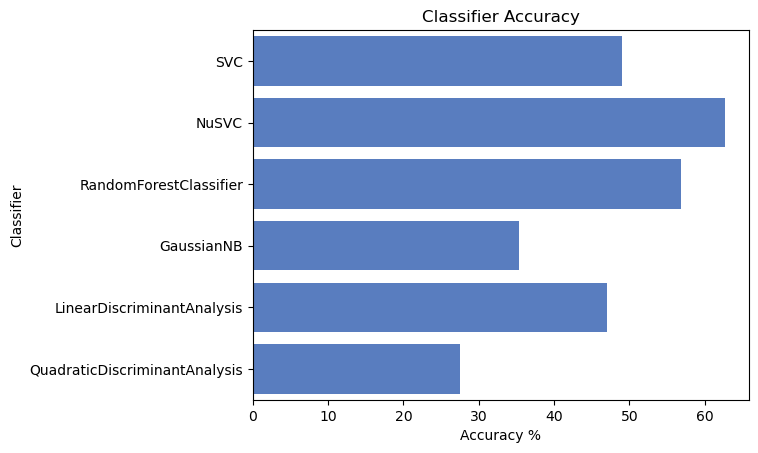

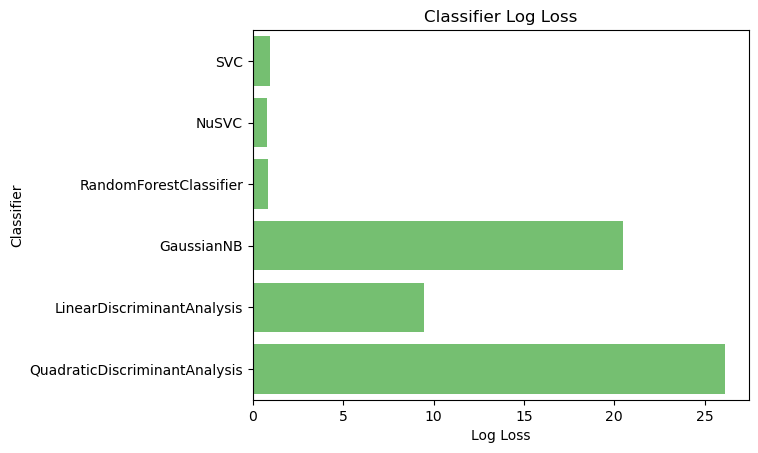

In [16]:
from sklearn.metrics import accuracy_score, log_loss
from sklearn.neighbors import KNeighborsClassifier  # k近邻算法
from sklearn.svm import SVC, LinearSVC, NuSVC   #支持向量机分类器、线性支持向量机分类器、核支持向量分类
from sklearn.tree import DecisionTreeClassifier   # 决策树
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier   # 随机森林、AdaBoost、GradientBoost
from sklearn.naive_bayes import GaussianNB    #朴素贝叶斯GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis   #线性判别分析
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis   #二次判别分析
import pandas as pd 
import seaborn as sns

classifiers = [
#    KNeighborsClassifier(2),
    SVC(kernel="rbf",probability=True),
    NuSVC(probability=True),
#    DecisionTreeClassifier(),
    RandomForestClassifier(),
#    AdaBoostClassifier(),
#    GradientBoostingClassifier(),
     GaussianNB(),
    LinearDiscriminantAnalysis(solver='svd'),
    QuadraticDiscriminantAnalysis()]

# 结果可视化
log_cols=["Classifier", "Accuracy", "Log Loss"]
log = pd.DataFrame(columns=log_cols)

for clf in classifiers:
    clf.fit(Xtrain, Ytrain)
    name = clf.__class__.__name__

    print("="*30)
    print(name)

    print('****Results****')
    train_predictions = clf.predict(Xtest)
    acc = accuracy_score(Ytest, train_predictions)
    print("Accuracy: {:.4%}".format(acc))

    train_predictions = clf.predict_proba(Xtest)
    ll = log_loss(Ytest, train_predictions)
    print("Log Loss: {}".format(ll))

    log_entry = pd.DataFrame([[name, acc*100, ll]], columns=log_cols)
    log = log._append(log_entry)

print("="*30)
sns.set_color_codes("muted")
sns.barplot(x='Accuracy', y='Classifier', data=log, color="b")

plt.xlabel('Accuracy %')
plt.title('Classifier Accuracy')
plt.show()

sns.set_color_codes("muted")
sns.barplot(x='Log Loss', y='Classifier', data=log, color="g")

plt.xlabel('Log Loss')
plt.title('Classifier Log Loss')
plt.show()

D:\anaconda\envs\HDEEG\lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


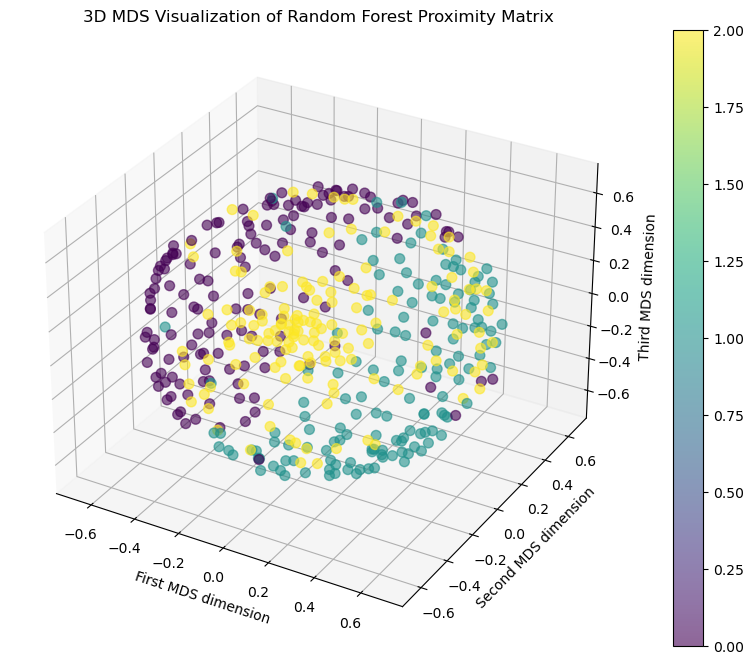

In [17]:
import numpy as np  
import pandas as pd  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.manifold import MDS  
import matplotlib.pyplot as plt  

# 1. 训练随机森林  
rf = RandomForestClassifier(n_estimators=100)  
rf.fit(Xtrain, Ytrain) 

# 2. 计算样本间的相似度矩阵  
def proximity_matrix(rf, Xtrain):  
    terminals = rf.apply(Xtrain)  
    n_samples = Xtrain.shape[0]  
    proximity = np.zeros((n_samples, n_samples))  
    
    for tree in range(terminals.shape[1]):  
        for i in range(n_samples):  
            for j in range(i, n_samples):  
                if terminals[i, tree] == terminals[j, tree]:  
                    proximity[i, j] += 1  
                    proximity[j, i] += 1  
    
    return proximity / terminals.shape[1]  

prox_matrix = proximity_matrix(rf, Xtrain)  
dissimilarity = 1 - prox_matrix  

# 3. 使用MDS进行降维  
mds = MDS(n_components=3, dissimilarity='precomputed')  
X_mds_3d = mds.fit_transform(dissimilarity)  

# 4. 绘图  
fig = plt.figure(figsize=(12, 8))  
ax = fig.add_subplot(111, projection='3d')  

# 绘制散点图  
scatter = ax.scatter(X_mds_3d[:, 0],   
                    X_mds_3d[:, 1],   
                    X_mds_3d[:, 2],  
                    c=Ytrain,  
                    cmap='viridis',  
                    s=50,  
                    alpha=0.6)  

# 添加颜色条  
plt.colorbar(scatter)  

# 设置标签  
ax.set_xlabel('First MDS dimension')  
ax.set_ylabel('Second MDS dimension')  
ax.set_zlabel('Third MDS dimension')  
ax.set_title('3D MDS Visualization of Random Forest Proximity Matrix')  

plt.savefig('E:/EMBC/results/jiao.svg')
# 添加交互性：可以旋转查看  
plt.show() 


C:\Users\PC233\AppData\Local\Temp\ipykernel_20040\4181796013.py:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


Training Random Forest...
Calculating proximity matrix...
Performing MDS...


D:\anaconda\envs\HDEEG\lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


Creating visualization...


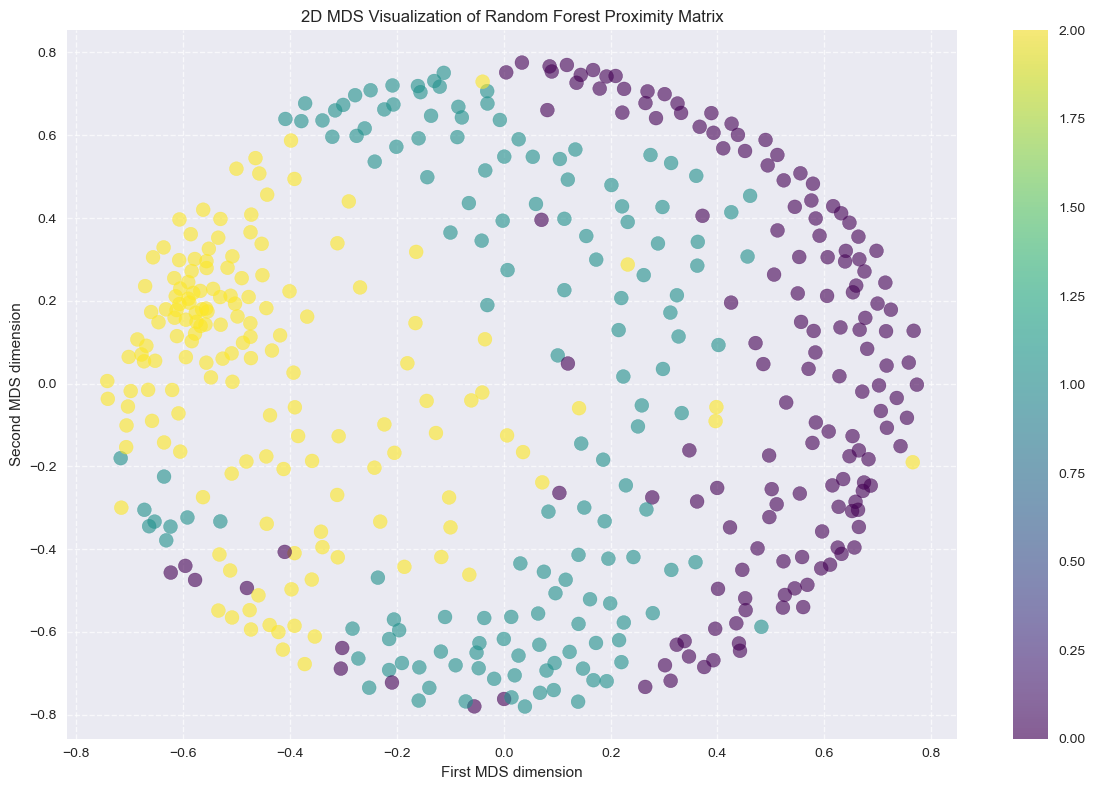

Number of samples: 453
Number of features: 384
Number of classes: 3
MDS stress value: 13394.3872


In [18]:
import numpy as np  
import pandas as pd  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.manifold import MDS  
import matplotlib.pyplot as plt  
import seaborn as sns  

# 设置绘图风格  
plt.style.use('seaborn')  
sns.set_palette('husl')  

# 1. 训练随机森林  
print("Training Random Forest...")  
rf = RandomForestClassifier(n_estimators=100, random_state=42)  
rf.fit(Xtrain, Ytrain)  

# 2. 计算样本间的相似度矩阵  
def proximity_matrix(rf, Xtrain):  
    print("Calculating proximity matrix...")  
    terminals = rf.apply(Xtrain)  
    n_samples = Xtrain.shape[0]  
    proximity = np.zeros((n_samples, n_samples))  
    
    for tree in range(terminals.shape[1]):  
        for i in range(n_samples):  
            for j in range(i, n_samples):  
                if terminals[i, tree] == terminals[j, tree]:  
                    proximity[i, j] += 1  
                    proximity[j, i] += 1  
    
    return proximity / terminals.shape[1]  

# 计算相似度矩阵  
prox_matrix = proximity_matrix(rf, Xtrain)  
dissimilarity = 1 - prox_matrix  

# 3. 使用MDS进行降维（改为2维）  
print("Performing MDS...")  
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)  
X_mds_2d = mds.fit_transform(dissimilarity)  

# 4. 绘图  
print("Creating visualization...")  
plt.figure(figsize=(12, 8))  

# 创建散点图  
scatter = plt.scatter(X_mds_2d[:, 0],   
                     X_mds_2d[:, 1],  
                     c=Ytrain,  
                     cmap='viridis',  
                     s=100,  # 点的大小  
                     alpha=0.6)  # 透明度  

# 添加颜色条  
plt.colorbar(scatter)  

# 设置标签和标题  
plt.xlabel('First MDS dimension')  
plt.ylabel('Second MDS dimension')  
plt.title('2D MDS Visualization of Random Forest Proximity Matrix')  

# 添加网格  
plt.grid(True, linestyle='--', alpha=0.7)  

# 优化布局  
plt.tight_layout()  

# 显示图形  
plt.show()  

# 输出一些基本统计信息  
print(f"Number of samples: {len(Xtrain)}")  
print(f"Number of features: {Xtrain.shape[1]}")  
print(f"Number of classes: {len(np.unique(Ytrain))}")  

# 计算和打印应力值（stress value）  
stress = mds.stress_  
print(f"MDS stress value: {stress:.4f}")  

In [19]:
import os
from numpy import loadtxt
import xgboost as xgb
from numpy import sort
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn import svm
from sklearn import datasets
from xgboost import plot_importance
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectFromModel
import warnings
from matplotlib import  pyplot
import matplotlib.pyplot as plt
import matplotlib.pyplot as plot
warnings.filterwarnings("ignore")
# 加载数据集

CV accuracy scores:[0.73913043 0.69565217 0.60869565 0.73333333 0.6        0.68888889
 0.68888889 0.64444444 0.57777778 0.6       ]
Accuracy for XGBoost Classifier :  0.6576811594202898
[5.47003059e-04 6.99596363e-04 1.10273017e-03 2.97337305e-04
 3.47461994e-03 2.77557550e-03 5.49367920e-04 5.01458417e-04
 1.22422271e-03 1.30309386e-03 4.73930221e-03 6.54933567e-04
 5.05326498e-05 1.44354068e-03 0.00000000e+00 4.08780761e-03
 1.01089908e-03 2.33676285e-03 7.62588286e-04 9.76021518e-04
 2.57418491e-03 5.87226241e-04 2.03262796e-04 2.76816008e-03
 4.21744306e-03 3.81573313e-03 8.89575982e-04 3.68964626e-03
 1.62798597e-03 0.00000000e+00 1.70264067e-03 1.49098423e-03
 4.66607464e-03 2.94120377e-03 9.92907793e-04 1.65668011e-04
 9.50182322e-04 9.45872802e-04 2.01672805e-03 1.70536700e-03
 2.56582559e-03 1.63335633e-03 2.65294174e-03 5.74584003e-04
 3.77247139e-04 1.35308073e-03 1.59269676e-03 1.32576900e-03
 0.00000000e+00 5.00053028e-03 4.72372444e-03 4.68850462e-03
 1.89503271e-03 1.454

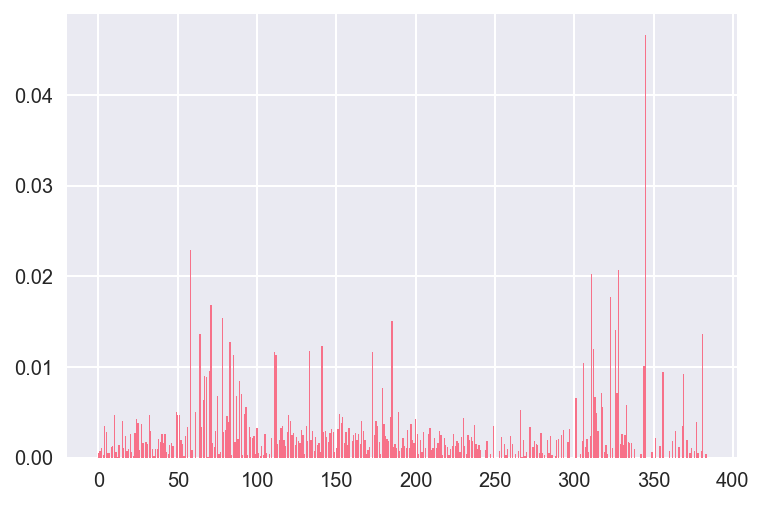

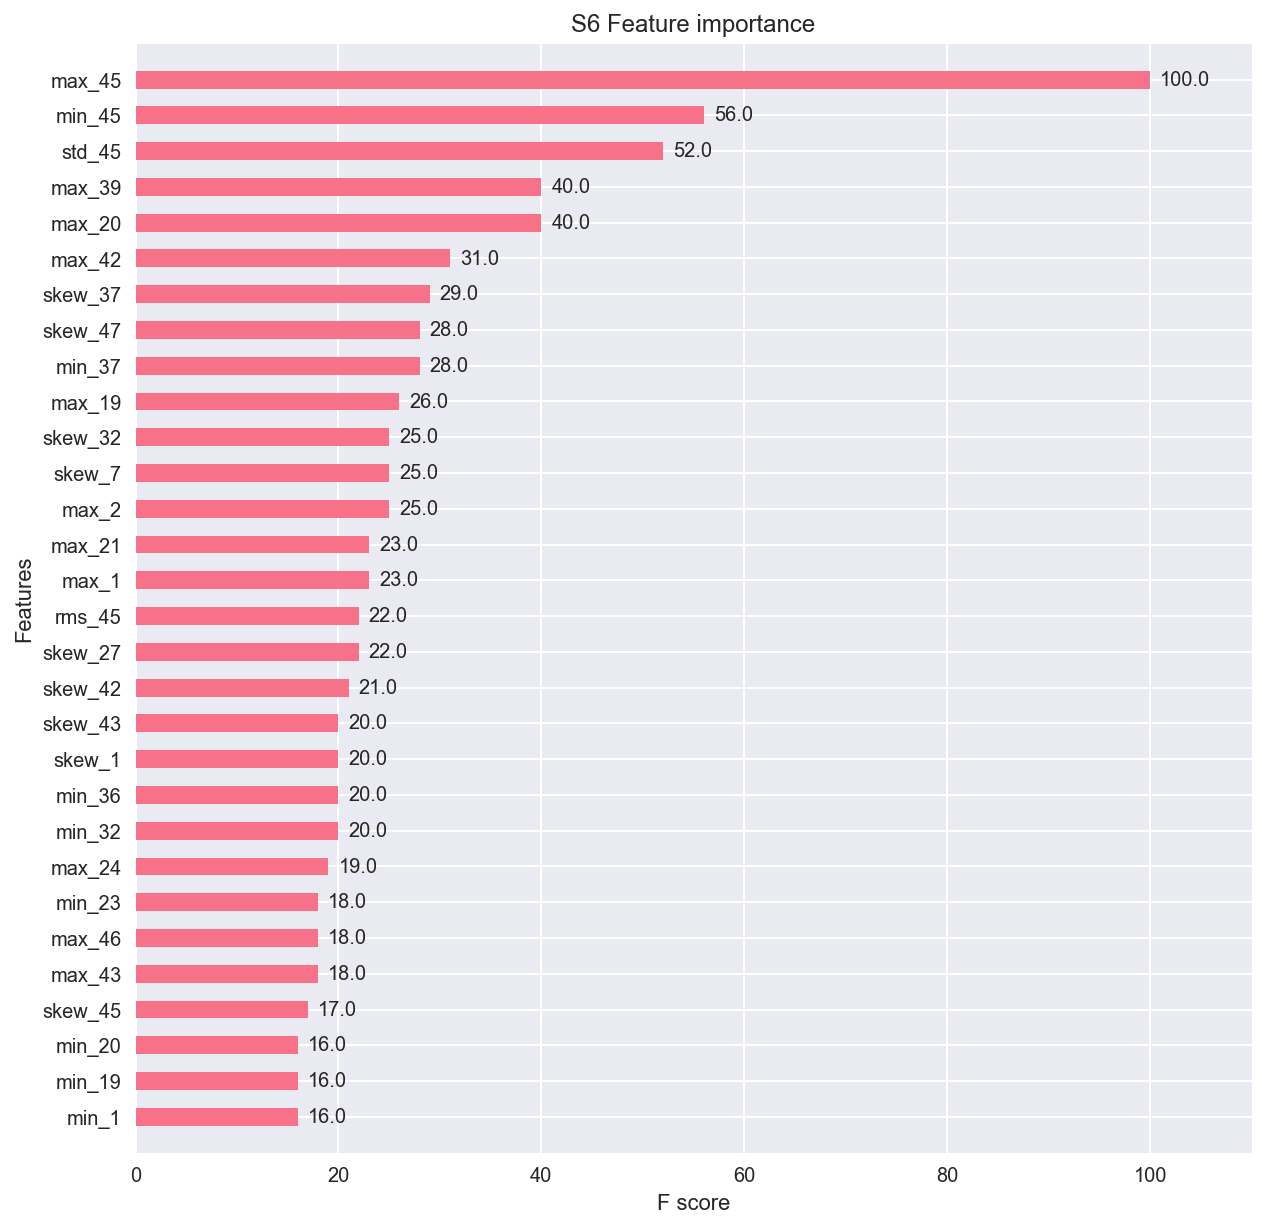

In [21]:
          #数据预处理---scale标准化

model=XGBClassifier(objective='multi:softmax',
                                                       n_estimators=150,  # 迭代次数
                                                       learning_rate=0.2,  # 步长
                                                       max_depth=3,  # 树的最大深度
                                                       min_child_weight=1,  # 决定最小叶子节点样本权重和
                                                    
                                                      subsample=0.8,  # 每个决策树所用的子样本占总样本的比例（作用于样本）
                                                       colsample_bytree=0.8, 

                                                     )

#model = XGBClassifier()
model.fit(Xtrain, Ytrain)




scores = cross_val_score(model, Xtrain, Ytrain, cv=10)
print("CV accuracy scores:%s" % scores)
print('Accuracy for XGBoost Classifier : ', scores.mean())
# 变量重要性列表
print(model.feature_importances_)

# 变量重要性可视化

plt.figure(figsize=(6,4), dpi=144)
pyplot.bar(range(len(model.feature_importances_)), model.feature_importances_)


# 变量重要性排序可视化

 
fig,ax = plt.subplots(figsize=(10,10), dpi=144)
plot_importance(model,
                height=0.5,
                ax=ax,
                 title='S6 Feature importance',
                max_num_features=30,
             )
plt.savefig('E:/高密度脑电前额项目/code/EEG/feature_analysis/HD/results/S2_features.svg')



    

In [ ]:
# make predictions for test data and evaluate
y_pred = model.predict(Xtest)
predictions = [round(value) for value in y_pred]
accuracy = accuracy_score(Ytest, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))


#plot_importance(pl_xgb)
thresholds = sort(model.feature_importances_)
print(thresholds)



acc = []
for thresh in thresholds: # 遍历所有的特征重要性得分，把每个得分作为阈值进行特征选择
    # select features using threshold
    selection = SelectFromModel(model, threshold=thresh, prefit=True)
    select_Xtrain = selection.transform(Xtrain)
# train model
    selection_model = XGBClassifier()
    selection_model.fit(select_Xtrain, Ytrain)
# eval model
    select_Xtest = selection.transform(Xtest)
    y_pred = selection_model.predict(select_Xtest)
    predictions = [round(value) for value in y_pred]
    accuracy = accuracy_score(Ytest, predictions)
    
   
    acc.append(accuracy)
    print("Thresh=%.3f, n=%d, Accuracy: %.2f%%" % (thresh, select_Xtrain.shape[1], accuracy*100.0))

print(acc)

In [22]:
print(type(Xtrain))

<class 'pandas.core.frame.DataFrame'>


In [23]:
# 检查数据类型并打印原始信息  
print("原始数据信息:")  
print("Xtrain类型:", type(Xtrain))  
print("Xtrain形状:", Xtrain.shape)  

# 将DataFrame转换为numpy数组  
Xtrain = Xtrain.values  
print("\n转换后:")  
print("Xtrain类型:", type(Xtrain))  
print("Xtrain形状:", Xtrain.shape)  

# 确保数据类型是浮点型  
Xtrain = Xtrain.astype(np.float32)  

# 检查数据是否正确转换  
print("\n数据检查:")  
print("数据类型:", Xtrain.dtype)  
print("是否有缺失值:", np.any(np.isnan(Xtrain)))  
print("是否有无穷值:", np.any(np.isinf(Xtrain)))

原始数据信息:
Xtrain类型: <class 'pandas.core.frame.DataFrame'>
Xtrain形状: (453, 384)

转换后:
Xtrain类型: <class 'numpy.ndarray'>
Xtrain形状: (453, 384)

数据检查:
数据类型: float32
是否有缺失值: False
是否有无穷值: False


In [24]:
from sklearn.manifold import TSNE
import time
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
%matplotlib inline

import seaborn as sns
sns.set_style('darkgrid')
sns.set_palette('muted')
sns.set_context("notebook", font_scale=1.5,
                rc={"lines.linewidth": 2.5})
RS = 123


time_start = time.time()

fashion_tsne = TSNE(random_state=RS, n_jobs=-1).fit_transform(Xtrain)

print(f't-SNE done! Time elapsed: {time.time()-time_start} seconds')



AttributeError: 'NoneType' object has no attribute 'split'

In [ ]:
import matplotlib.pyplot as plt



plt.show()
plt.figure(figsize=(6,4), dpi=144)
plt.grid()
plt.xlabel("feature importance")
plt.ylabel("Accuracy")
plt.plot( thresholds,acc, label='selection')
#plt.savefig('./output/img_S6cur32.svg')
plt.legend()

In [ ]:
print(Ytest)
a=np.count_nonzero(Ytest == 1)#Neg
b=np.count_nonzero(Ytest == 2)#Pos
c=np.count_nonzero(Ytest == 0)#Neu
print(a)
print(b)
print(c)

In [25]:
#多分类：混淆矩阵

from sklearn.metrics import confusion_matrix

cfm = confusion_matrix(Ytest,y_pred)
cfm_normalized = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]
print(cfm_normalized)
print(cfm)

[[0.33333333 0.26666667 0.4       ]
 [0.27272727 0.09090909 0.63636364]
 [0.07142857 0.21428571 0.71428571]]
[[ 5  4  6]
 [ 6  2 14]
 [ 1  3 10]]


<Axes: >

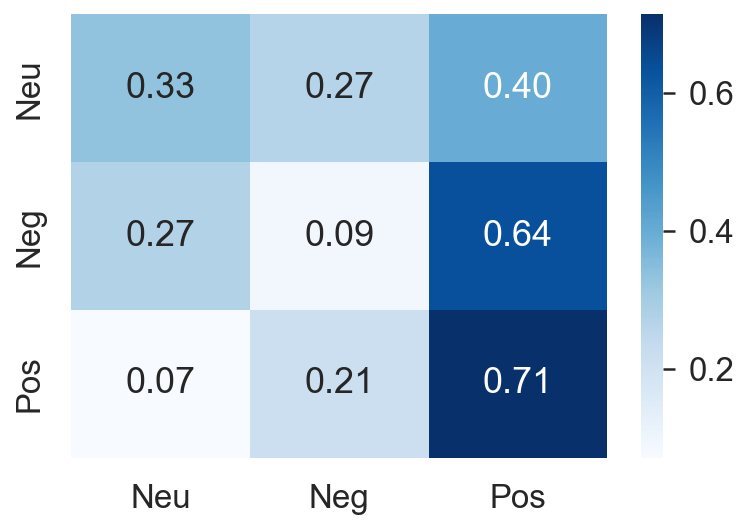

In [26]:
import seaborn as sns

labels=["Neu","Neg","Pos"]
plt.figure(figsize=(6,4), dpi=144)
plt.xlabel("S6")
sns.heatmap(cfm_normalized,annot=True,cmap='Blues',xticklabels=labels,yticklabels= labels,fmt='.2f')



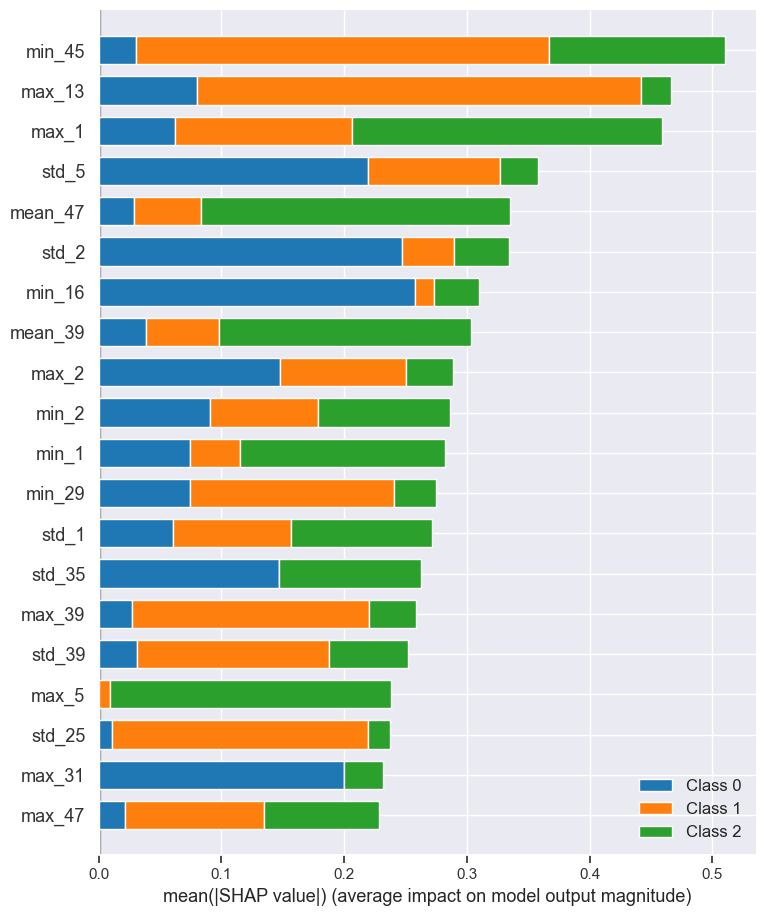

<Figure size 640x480 with 0 Axes>

In [178]:
import shap
import matplotlib.pyplot as pl


explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(Xtrain)

shap.summary_plot(shap_values, Xtrain,color=pl.get_cmap("tab10"))
shap_values[1][:2,:]#表示前两个样本对于输出标签为1的shap值
plt.savefig('E:/高密度脑电前额项目/code/EEG/feature_analysis/HD/results/1.jpg')

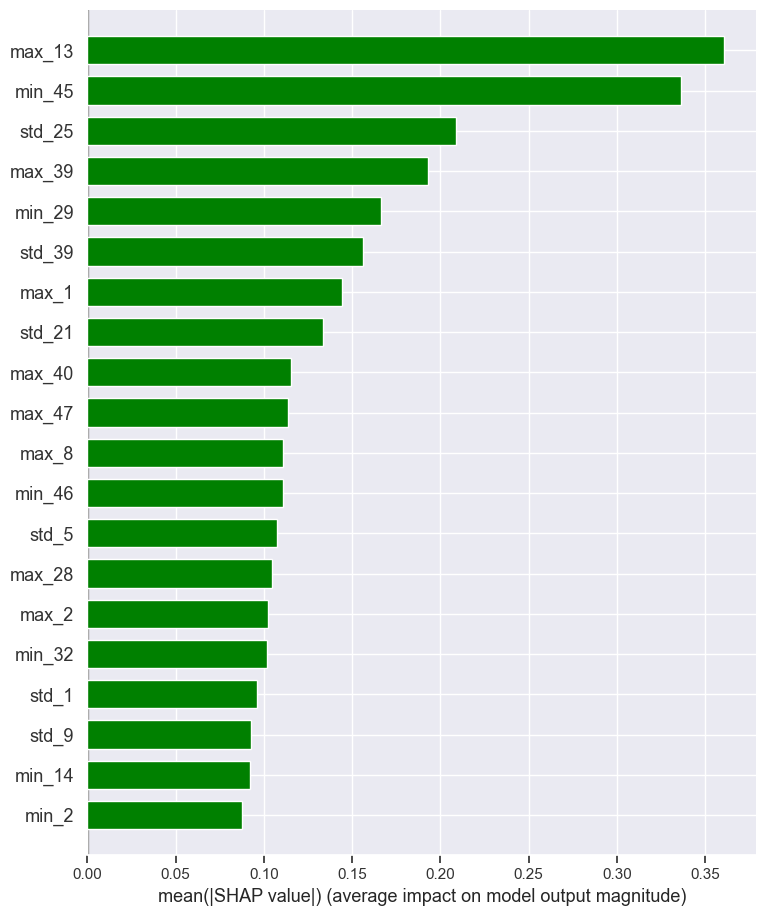

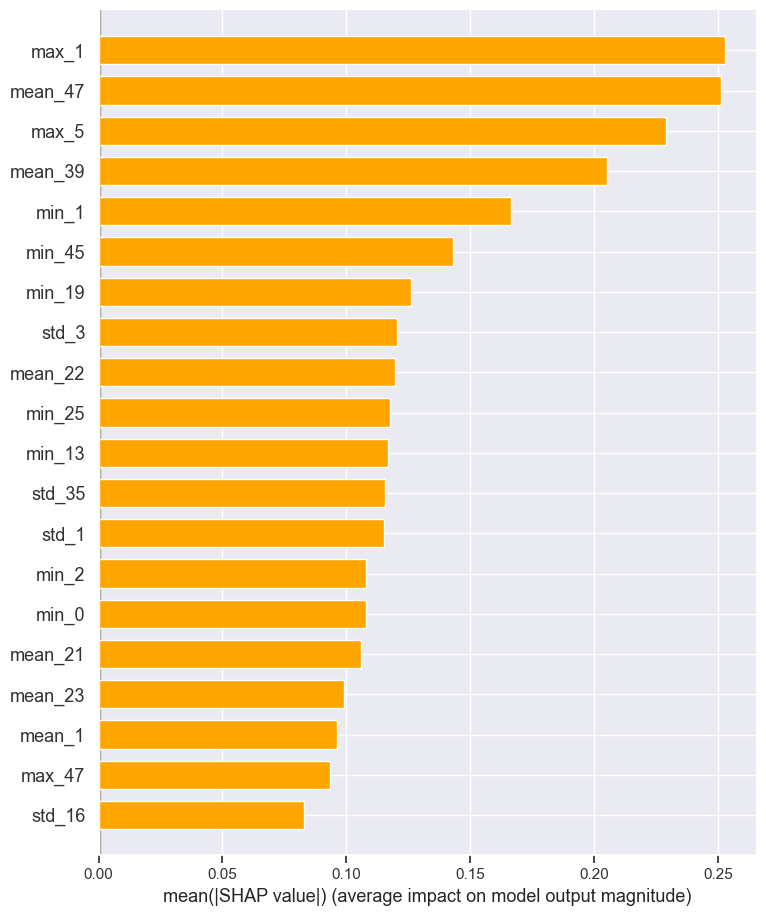

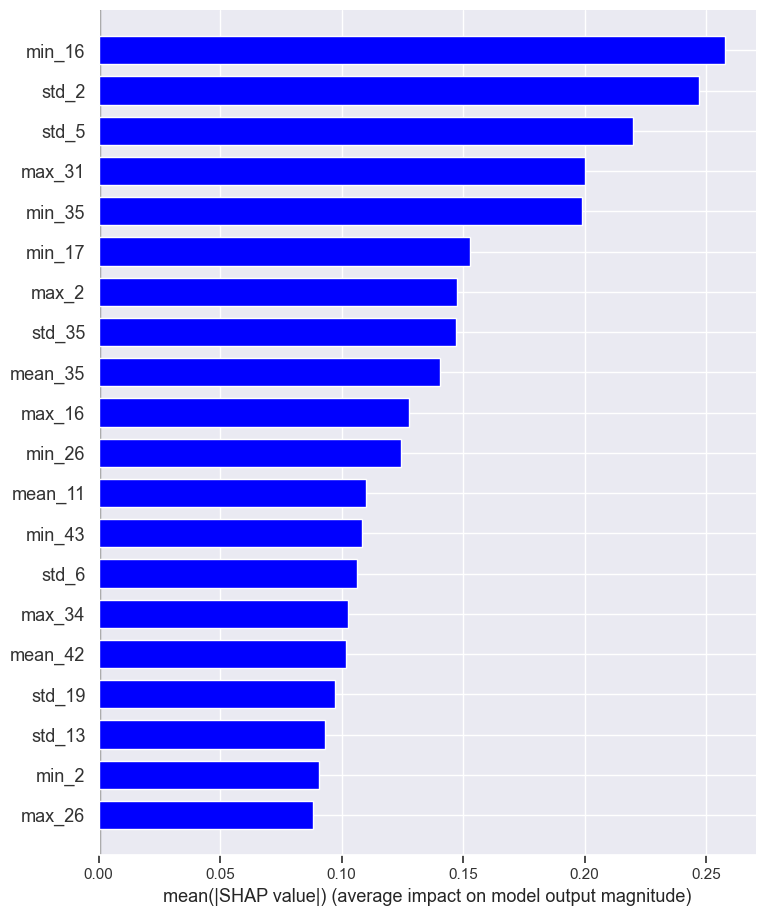

In [174]:
shap.summary_plot(shap_values[1],Xtest, plot_type="bar",color='green')
shap.summary_plot(shap_values[2],Xtest, plot_type="bar",color='orange')
shap.summary_plot(shap_values[0],Xtest, plot_type="bar",color='blue')

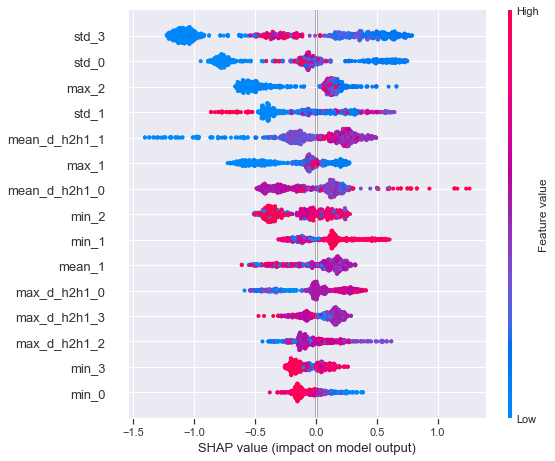

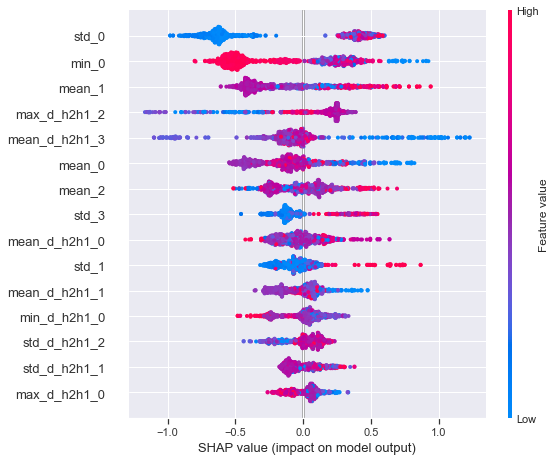

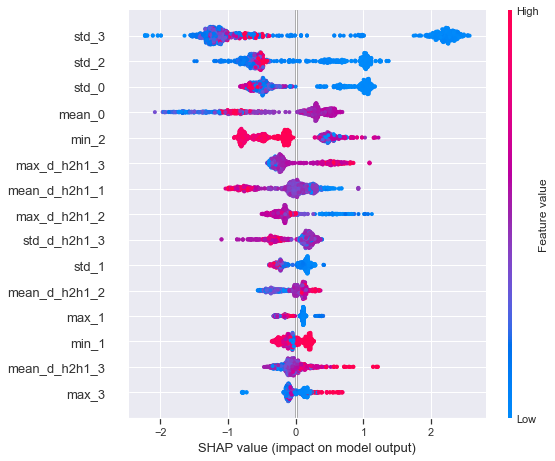

In [29]:
# SHAP值解释
shap.summary_plot(shap_values[1], Xtrain, max_display=15)#消极情感

shap.summary_plot(shap_values[2], Xtrain, max_display=15)#积极情感
shap.summary_plot(shap_values[0], Xtrain, max_display=15)#中性情感

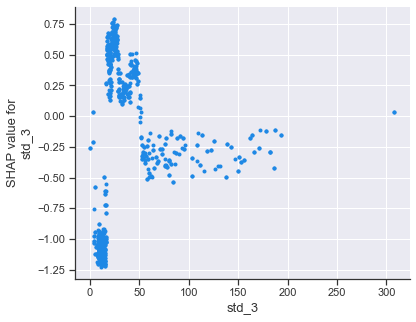

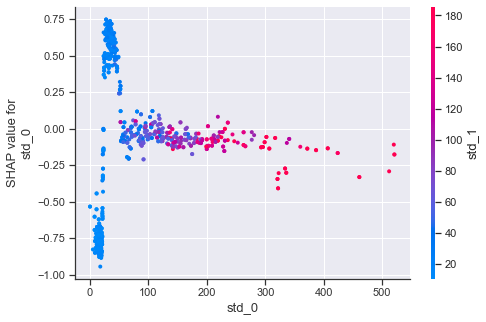

In [30]:
# 单个特征'dangou_ratio'与模型预测结果的关系
shap.dependence_plot('std_3', shap_values[1],Xtrain[x.columns], display_features=Xtrain[x.columns],interaction_index=None)
shap.dependence_plot('std_0', shap_values[1],Xtrain[x.columns], display_features=Xtrain[x.columns],interaction_index='auto')

# ---------------------------分割线-----------------------------

# Embedded嵌入法

In [31]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier as RFC

In [32]:
RFC_ = RFC(n_estimators=10,random_state=0)  # 随机森林实例化

In [33]:
x = data_.iloc[:,:-2]
y = data_.iloc[:,-1]
x.shape

NameError: name 'data_' is not defined

* 阈值为0.005

In [ ]:
x_embedded = SelectFromModel(RFC_,threshold=0.005).fit_transform(x,y)
#在这里我只想取出来有限的特征。0.005这个阈值对于有780个特征的数据来说，是非常高的阈值，因为平均每个特征
# 只能够分到大约0.001的feature_importances_

In [ ]:
x_embedded.shape
#模型的维度明显被降低了
#同样的，我们也可以画学习曲线来找最佳阈值

In [ ]:
RFC_.fit(x,y).feature_importances_

In [ ]:
(RFC_.fit(x,y).feature_importances_).max()

In [ ]:
# 绘制学习曲线
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
RFC_.fit(x,y).feature_importances_
threshold = np.linspace(0,(RFC_.fit(x,y).feature_importances_).max(),20)
#0 - feature_importances_ 范围中取20个数

score = []
for i in threshold:
    x_embedded = SelectFromModel(RFC_,threshold=i).fit_transform(x,y) # 随机森林实例化
    once = cross_val_score(RFC_,x_embedded,y,cv=5).mean()  # 交叉验证5次
    score.append(once)
plt.plot(threshold,score)
plt.show()

In [ ]:
threshold

In [ ]:
x_embedded = SelectFromModel(RFC_,threshold=0.00870999).fit_transform(x,y)

In [ ]:
x_embedded.shape

In [ ]:
cross_val_score(RFC_,x_embedded,y,cv=5).mean()

In [ ]:
# 确定准确率最高threshold值


score2 = []
for i in np.linspace(0,0.00870999,20):
    x_embedded = SelectFromModel(RFC_,threshold=i).fit_transform(x,y)
    once = cross_val_score(RFC_,x_embedded,y,cv=5).mean()
    score2.append(once)
plt.figure(figsize=[20,5])
plt.plot(np.linspace(0,0.00870999,20),score2)
plt.xticks(np.linspace(0,0.00870999,20))
plt.show()

In [ ]:
x_embedded = SelectFromModel(RFC_,threshold=0.003209).fit_transform(x,y)

In [ ]:
x_embedded.shape

In [ ]:
cross_val_score(RFC_,x_embedded,y,cv=5).mean()

In [ ]:
cross_val_score(RFC(n_estimators=100,random_state=0),x_embedded,y,cv=5).mean()

* 阈值为0.001

In [ ]:
x_embedded = SelectFromModel(RFC_,threshold=0.001).fit_transform(x,y)
#在这里我只想取出来有限的特征。0.005这个阈值对于有780个特征的数据来说，是非常高的阈值，因为平均每个特征
# 只能够分到大约0.001的feature_importances_

In [ ]:
x_embedded.shape

In [ ]:
RFC_.fit(x,y).feature_importances_

In [ ]:
(RFC_.fit(x,y).feature_importances_).max()

In [ ]:
# 绘制学习曲线
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
RFC_.fit(x,y).feature_importances_
threshold = np.linspace(0,(RFC_.fit(x,y).feature_importances_).max(),20)
#0 - feature_importances_ 范围中取20个数

score = []
for i in threshold:
    x_embedded = SelectFromModel(RFC_,threshold=i).fit_transform(x,y) # 随机森林实例化
    once = cross_val_score(RFC_,x_embedded,y,cv=5).mean()  # 交叉验证5次
    score.append(once)
plt.plot(threshold,score)
plt.show()

In [ ]:
threshold

# Wrapper包装法

In [ ]:
from sklearn.feature_selection import RFE
RFC_ = RFC(n_estimators=10,random_state=0)
selector = RFE(RFC_,n_features_to_select=22,step=5).fit(x,y)  # 每迭代一次删除掉50个特征

In [ ]:
selector.support_.sum() #.support_：返回所有的特征的是否最后被选中的布尔矩阵

In [ ]:
selector.ranking_   #返回特征的按数次迭代中综合重要性的排名,越重要的特征排在前面

In [ ]:
x_wrapper = selector.transform(x)

In [ ]:
cross_val_score(RFC_,x_wrapper,y,cv=5).mean()

In [ ]:
# 绘制学习曲线
score = []
for i in range(1,751,50):
    x_wrapper = RFE(RFC_,n_features_to_select=i, step=50).fit_transform(x,y)
    once = cross_val_score(RFC_,x_wrapper,y,cv=5).mean()
    score.append(once)
plt.figure(figsize=[20,5])
plt.plot(range(1,751,50),score)
plt.xticks(range(1,751,50))
plt.show()